In [1]:
import sys
import os
sys.path.append('../data/toy_datasets/')
from toyDataWithDensity import make_circle_varying_density

In [7]:
sys.path.append('../trajectory_inference/')
import anndata as ad
import numpy as np
import pandas as pd
from diffusion_maps import kTilde, diffusion_map_from_Ktilde
from Laplacian_Eigenmaps import loadAndCSR, laplacianEigenmaps
from trajectory_validation import align_circular_pseudotime, aligned_circular_agreement
from density_experiment import radius_cv, mean_abs_wrapped_error

density_df = make_circle_varying_density(density_ratio=4,noise=0.3)
density_df
obs = density_df[['angle']].copy()
obs.index = [f"k{20}_noise{0.3}_dr{4}_seed{0}_cell{i}" for i in range(len(obs))]
adata = ad.AnnData(X=density_df[['x', 'y']].to_numpy(), obs=obs)
adata.obs['noise'] = 0.3
adata.obs['density_ratio'] = 4
adata.obs['n_points'] = 500
adata.obs['k'] = 20
adata.obsm['X_pca'] = adata.X

# initialize CSR
csr = loadAndCSR(adata, k=20)
# LE
lap, eigvals = laplacianEigenmaps(csr, nComponents=5)

# DM
kT = kTilde(csr,alpha=0.5)
diff, lambdas, psis = diffusion_map_from_Ktilde(kT, n_components=5)

# center data
lap = lap - lap.mean(axis=0)
adata.obsm['lap_embed'] = lap
diff = diff - diff.mean(axis=0)
adata.obsm['dm_embed'] = diff

# compute aligned pseudotime
dpt = np.arctan2(diff[:,0],diff[:,1])
dpt = align_circular_pseudotime(adata.obs['angle'],dpt)['aligned']
lpt = np.arctan2(lap[:,0],lap[:,1])
lpt = align_circular_pseudotime(adata.obs['angle'],lpt)['aligned']
adata.obs['lpt'] = lpt
adata.obs['dpt'] = dpt
mwe = [mean_abs_wrapped_error(adata.obs['angle'].values,dpt),mean_abs_wrapped_error(adata.obs['angle'].values,lpt)]
rad_cv = [radius_cv(diff[:,:2]),radius_cv(lap[:,:2])]
circ_agr = [aligned_circular_agreement(adata.obs['angle'].values,dpt),aligned_circular_agreement(adata.obs['angle'].values,lpt)]
metric_annot = pd.DataFrame(data=[['DM'],['LE']],columns=['Method'])
metric_annot['circular agreement'] = circ_agr
metric_annot['radius CV'] = rad_cv
metric_annot['mean angular error'] = mwe
metric_annot

,Method,circular agreement,radius CV,mean angular error
0,DM,0.850800,0.162240,0.463307
1,LE,0.402792,0.471917,1.069251


### Plot density/noise experiment results

In [8]:
import pandas as pd
results = pd.read_csv('../data/toy_datasets/density_noise_exp_metrics.csv')

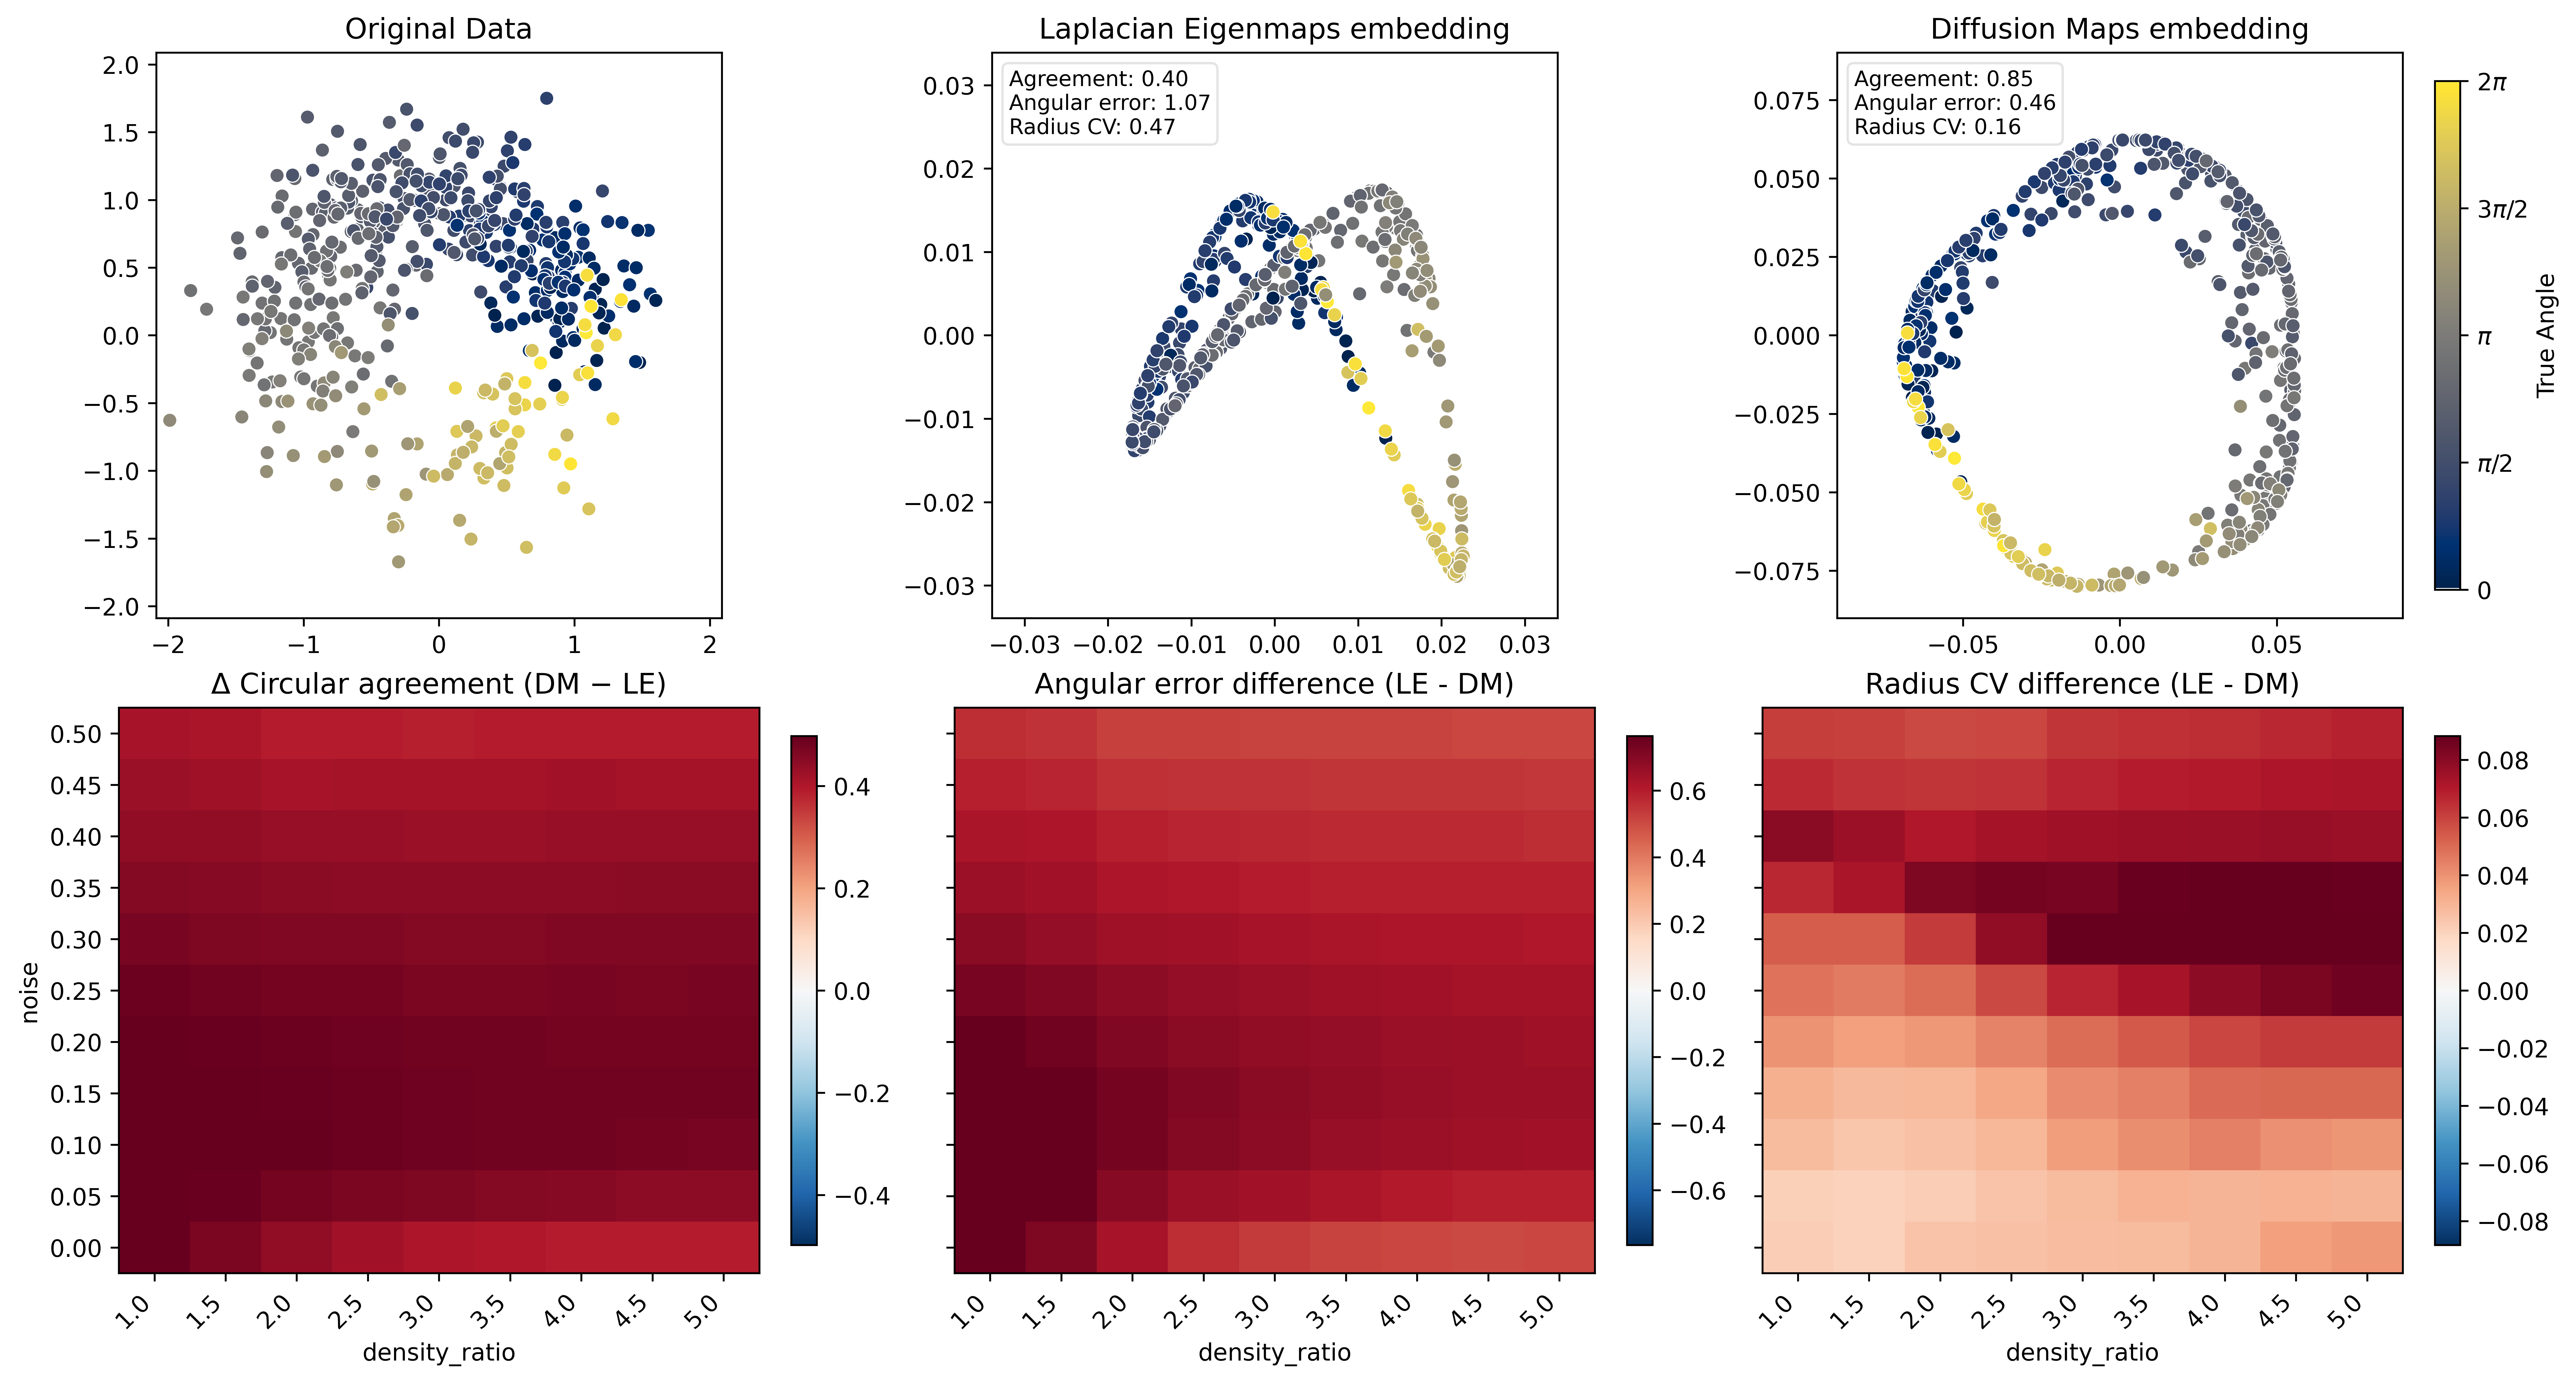

In [16]:
# plotting results
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assumes your dataframe is called df
# Columns:
# ['Method', 'aligned_circular_agreement', 'mean_abs_wrapped_error',
#  'radius_cv', 'noise', 'density_ratio', 'seed', 'k', 'n_points']

# -----------------------------
# 1) Aggregate over trials/seeds
# -----------------------------
summary = (
    results.groupby(["Method", "noise", "density_ratio", "k"], as_index=False)
      .agg(
          aligned_circular_agreement_mean=("aligned_circular_agreement", "mean"),
          aligned_circular_agreement_sem=("aligned_circular_agreement", "sem"),
          mean_abs_wrapped_error_mean=("mean_abs_wrapped_error", "mean"),
          mean_abs_wrapped_error_sem=("mean_abs_wrapped_error", "sem"),
          radius_cv_mean=("radius_cv", "mean"),
          radius_cv_sem=("radius_cv", "sem"),
      )
)

# -----------------------------
# 2) Difference tables: DM - LE
# -----------------------------
wide = summary.pivot_table(
    index=["noise", "density_ratio", "k"],
    columns="Method",
    values=[
        "aligned_circular_agreement_mean",
        "mean_abs_wrapped_error_mean",
        "radius_cv_mean",
    ]
)


# Flatten columns
wide.columns = [f"{metric}_{method}" for metric, method in wide.columns]
wide = wide.reset_index()

# Positive means DM better for all three derived metrics below
wide["agreement_diff_DM_minus_LE"] = (
    wide["aligned_circular_agreement_mean_DM"] - wide["aligned_circular_agreement_mean_LE"]
)
wide["wrapped_error_advantage_DM"] = (
    wide["mean_abs_wrapped_error_mean_LE"] - wide["mean_abs_wrapped_error_mean_DM"]
)
wide["radius_cv_advantage_DM"] = (
    wide["radius_cv_mean_LE"] - wide["radius_cv_mean_DM"]
)

# -----------------------------
# 2.5) Average over k
# -----------------------------
wide_k_avg = (
    wide.groupby(["noise", "density_ratio"], as_index=False)
        .agg({
            "agreement_diff_DM_minus_LE": "mean",
            "wrapped_error_advantage_DM": "mean",
            "radius_cv_advantage_DM": "mean",
        })
)

# -----------------------------
# 3) Helper: single heatmap
# -----------------------------
def plot_heatmap_no_k(
    data,
    value_col,
    ax=None,
    title=None,
    cmap="cividis",
    vmin=None,
    vmax=None,
):
    heat = data.pivot(index="noise", columns="density_ratio", values=value_col)
    heat = heat.sort_index().sort_index(axis=1)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(
        heat.values,
        aspect="auto",
        origin="lower",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks(np.arange(len(heat.columns)))
    ax.set_xticklabels([f"{x:.1f}" for x in heat.columns], rotation=45, ha="right")
    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_yticklabels([f"{y:.2f}" for y in heat.index])

    ax.set_xlabel("density_ratio")
    ax.set_ylabel("noise")
    ax.set_title(title)

    return im



fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True,dpi=600)
axes = axes.flat

norm = plt.Normalize(adata.obs['angle'].min(), adata.obs['angle'].max())
sm = plt.cm.ScalarMappable(cmap="cividis", norm=norm)
sm.set_array([]) # Required for matplotlib versions

# Plotting high noise, variable density examples

dm_annot = metric_annot[metric_annot["Method"] == "DM"].iloc[0]
le_annot = metric_annot[metric_annot["Method"] == "LE"].iloc[0]
dm_text = (
    f"Agreement: {dm_annot['circular agreement']:.2f}\n"
    f"Angular error: {dm_annot['mean angular error']:.2f}\n"
    f"Radius CV: {dm_annot['radius CV']:.2f}"
)

le_text = (
    f"Agreement: {le_annot['circular agreement']:.2f}\n"
    f"Angular error: {le_annot['mean angular error']:.2f}\n"
    f"Radius CV: {le_annot['radius CV']:.2f}"
)

sns.scatterplot(x=adata.X[:,0],y=adata.X[:,1],ax=axes[0],hue=adata.obs['angle'],palette='cividis',legend=False)
axes[0].set_aspect('equal')
axes[0].set_title('Original Data')
max_range = np.max(np.abs(adata.X)) + 0.1
axes[0].set_xlim([-max_range,max_range])
axes[0].set_ylim([-max_range,max_range])
sns.scatterplot(x=adata.obsm['lap_embed'][:,0],y=adata.obsm['lap_embed'][:,1],hue=adata.obs['angle'],ax=axes[1],palette='cividis',legend=False)
axes[1].set_aspect('equal',adjustable='box')
axes[1].set_title('Laplacian Eigenmaps embedding')
max_range = np.max(np.abs(adata.obsm['lap_embed'][:,:2])) + 0.005
axes[1].set_xlim([-max_range,max_range])
axes[1].set_ylim([-max_range,max_range])
axes[1].text(
    0.03, 0.97,
    le_text,
    transform=axes[1].transAxes,
    va="top",
    ha="left",
    fontsize=9,
    fontweight='medium',
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        alpha=0.6,
        edgecolor="lightgray"
    )
)

sns.scatterplot(x=adata.obsm['dm_embed'][:,0],y=adata.obsm['dm_embed'][:,1],hue=adata.obs['angle'],ax=axes[2],palette='cividis',legend=False)
axes[2].set_aspect('equal')
axes[2].set_title('Diffusion Maps embedding')
max_range = np.max(np.abs(adata.obsm['dm_embed'][:,:2])) + 0.01
axes[2].set_xlim([-max_range,max_range])
axes[2].set_ylim([-max_range,max_range])
axes[2].text(
    0.03, 0.97,
    dm_text,
    transform=axes[2].transAxes,
    va="top",
    ha="left",
    fontsize=9,
    fontweight='medium',
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        alpha=0.6,
        edgecolor="lightgray"
    )
)
cb = axes[2].figure.colorbar(sm, ax=axes[2], label='True Angle',shrink=0.9)
ticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
labels = ["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
cb.set_ticks(ticks)
cb.set_ticklabels(labels)


# Plotting density experiment results
# symmetric color scales
mx1 = np.percentile(np.abs(wide_k_avg["agreement_diff_DM_minus_LE"]),95)
mx2 = np.percentile(np.abs(wide_k_avg["wrapped_error_advantage_DM"]),95)
mx3 = np.percentile(np.abs(wide_k_avg["radius_cv_advantage_DM"]),95)

im1 = plot_heatmap_no_k(
    wide_k_avg,
    "agreement_diff_DM_minus_LE",
    ax=axes[3],
    title="Δ Circular agreement (DM − LE)",
    cmap="RdBu_r",
    vmin=-mx1,
    vmax=mx1,
)

im2 = plot_heatmap_no_k(
    wide_k_avg,
    "wrapped_error_advantage_DM",
    ax=axes[4],
    title="Angular error difference (LE - DM)",
    cmap="RdBu_r",
    vmin=-mx2,
    vmax=mx2,
)

im3 = plot_heatmap_no_k(
    wide_k_avg,
    "radius_cv_advantage_DM",
    ax=axes[5],
    title="Radius CV difference (LE - DM)",
    cmap="RdBu_r",
    vmin=-mx3,
    vmax=mx3,
)
for ax in axes[4:6]:
    ax.tick_params(labelleft=False)
    ax.set_ylabel('')
    ax.sharex(axes[4])
    ax.sharey(axes[4])
fig.colorbar(im1, ax=axes[3], shrink=0.9)
fig.colorbar(im2, ax=axes[4], shrink=0.9)
fig.colorbar(im3, ax=axes[5], shrink=0.9)
plt.show()
